# STA 141A: Predicting Wildfire Incidence in the United States
## Hoang Trang Thy Trinh ##

### Abstract


### Data Preprocessing

This section evaluates the quality of the input data and designs a data set that is suitable for **binary prediction of whether at least one notable fires will occur in each cell in grid-by-month unit**. The following items will be covered: 

- How notable fires are identified and filtered  
- How space–time units are constructed (grid x month)  
- How the binary outcome variable is defined  
- How predictors are constructed or aggregated  
- How missing data or edge cases are handled  

In [362]:
install.packages("e1071")
install.packages("caret")


The downloaded binary packages are in
	/var/folders/j8/qjq_kk4n1lzcfy_4x49w9lc40000gn/T//RtmpuD5FiD/downloaded_packages

The downloaded binary packages are in
	/var/folders/j8/qjq_kk4n1lzcfy_4x49w9lc40000gn/T//RtmpuD5FiD/downloaded_packages


In [363]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(pROC)
    library(rpart)
    library(rpart.plot)
    library(e1071)
    library(caret)
})

The USDA Forest Service metadata with 100,000 entries was loaded. This subset was derived from the Kaggle dataset *"188 Million US Wildfires"* (https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires).

In [364]:
wildfires <-read.csv(file = "/Users/thytrinh/Desktop/STA141AW26/Data/wildfires_sample_100k.csv")
glimpse(wildfires)

Rows: 100,000
Columns: 39
$ OBJECTID                   <int> 16, 68, 73, 111, 191, 228, 264, 269, 294, 3…
$ FOD_ID                     <int> 16, 68, 74, 112, 194, 231, 268, 274, 299, 3…
$ FPA_ID                     <chr> "FS-1418876", "FS-1419017", "FS-1419045", "…
$ SOURCE_SYSTEM_TYPE         <chr> "FED", "FED", "FED", "FED", "FED", "FED", "…
$ SOURCE_SYSTEM              <chr> "FS-FIRESTAT", "FS-FIRESTAT", "FS-FIRESTAT"…
$ NWCG_REPORTING_AGENCY      <chr> "FS", "FS", "FS", "FS", "FS", "FS", "FS", "…
$ NWCG_REPORTING_UNIT_ID     <chr> "USCAENF", "USMTKNF", "USMTKNF", "USCASNF",…
$ NWCG_REPORTING_UNIT_NAME   <chr> "Eldorado National Forest", "Kootenai Natio…
$ SOURCE_REPORTING_UNIT      <chr> "0503", "0114", "0114", "0515", "0302", "03…
$ SOURCE_REPORTING_UNIT_NAME <chr> "Eldorado National Forest", "Kootenai Natio…
$ LOCAL_FIRE_REPORT_ID       <chr> "103", "43", "33", "2", "279", "16", "37", …
$ LOCAL_INCIDENT_ID          <chr> "22", "015", "008", "01", "279", "06", "014…
$ FIRE_CODE   

The new subset is obtained with variables of interest. These variables cover the spatial and temporal components that can serve as predictors to the binary prediction model.

- `FIRE_YEAR`= Calendar year in which the fire was discovered or confirmed to exist.
- `DISCOVERY_DOY`= Day of year on which the fire was discovered or confirmed to exist.
- `FIRE_SIZE` = Estimate of burned area (acres).
- `LATITUDE`: Latitude of ignition point.
- `LONGITUDE`= Longitude of ignition point.
- `STATE`= Two-letter alphabetic code for the state where the fire burned.

Since most recorded fires are small, to reduce class imbalance that can negatively affect the efficiency of the prediction model, raw wildfire records are filtered using final burned area at the threshold of 300 acres - any values below 300 acres in `FIRE_SIZE` will be filtered out. The chosen threshold reflects the operational standard of the U.S. fire  management agencies when reporting large wildland fires, which is 300 acres in grass or brush fuel model. 

Information of the variables was obtained from https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires.

In [365]:
wildfires_300 <- wildfires |> 
    filter(FIRE_SIZE >= 300) |>
    select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) |>
    mutate(STATE = as.factor(STATE))

glimpse(wildfires_300)

Rows: 1,381
Columns: 6
$ FIRE_YEAR     <int> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ DISCOVERY_DOY <int> 197, 198, 219, 217, 224, 246, 178, 257, 173, 57, 108, 11…
$ FIRE_SIZE     <dbl> 1300, 495, 800, 817, 600, 1132, 1315, 1419, 3000, 332, 3…
$ LATITUDE      <dbl> 33.93361, 33.86250, 48.83417, 45.97667, 45.74833, 43.820…
$ LONGITUDE     <dbl> -111.37972, -111.15583, -115.18500, -114.96000, -115.165…
$ STATE         <fct> AZ, AZ, MT, ID, ID, ID, AZ, OR, AZ, KY, OK, AZ, AZ, CA, …


The data set is checked for `NA` values.

In [9]:
sum(is.na(wildfires_300))

[1] 0

Next, we visualize the data with density plot for each predictor variables (except `STATE`).

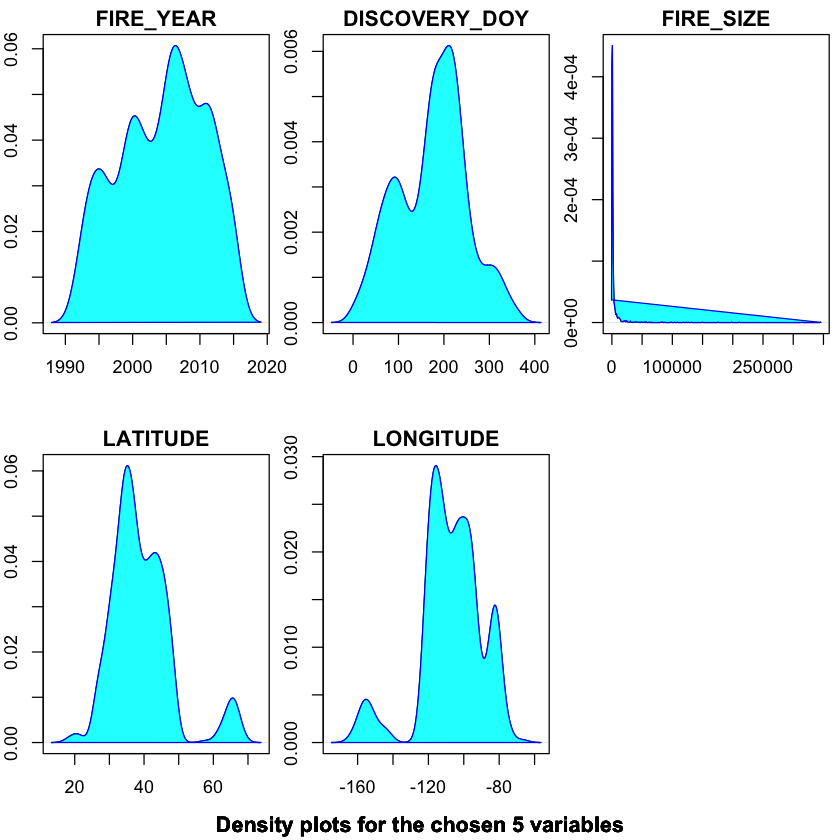

In [361]:
par(mfrow=c(2,3),mar=c(4, 2, 1.6, 0.5), cex = 0.9)

for (variables in 1:(dim(wildfires_300)[2]-1)){
  thisvar = wildfires_300[,variables]
  d <- density(thisvar)
  plot(d, main = names(wildfires_300[variables]),xlab="")
  polygon(d, col="cyan", border="blue")
  title("Density plots for the chosen 5 variables",line = -38.5, outer = TRUE)} 

As expected, temporal variables such as year and date of confirmed fires, `FIRE_YEAR` and `DISCOVERY_DOY` respectively, follows a relatively normal distribution. Same observation was made for `LATITUDE` and `LONGITUDE` of ignition points. 

`FIRE_SIZE` shows a heavy right skew even after filtering out values smaller than 300 acres, which accounts for roughly 86% of the input data set. This is due to rare and large fires that can reach over 300,000 acres. This predictor reflects true natural phenomenon of wildfire, which can help create a realistic prediction model. 

### Temporal Pattern

We convert `FIRE_YEAR` and `DISCOVERY_DOY` to `FIRE_DATE`. Now, `FIRE_DATE` is in the form of YYYY-MM-DD, from which `YEAR` and `MONTH` are extracted to become their own variables. 

In [371]:
wildfires_300 <- wildfires_300 %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

wildfires_300 %>% select("FIRE_DATE", "YEAR", "MONTH") %>% head

,FIRE_DATE,YEAR,MONTH
,<date>,<dbl>,<dbl>
1,2005-07-16,2005,7
2,2005-07-17,2005,7
3,2005-08-07,2005,8
4,2005-08-05,2005,8
5,2005-08-12,2005,8
6,2005-09-03,2005,9


### Spatial Pattern

In [374]:
wildfires_300 <- wildfires_300 %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH   
  )

We create a grid-month panel from the data set `wildfires_300`. Since we are retaining all notable fires with the size of >= 300 acres, `n_fires` for each entry will have at least 1 count of notable fire, and as expected, `fire_this_month` should show all "1", meaning at least one notable fire was confirmed to occur in that month during the recorded years.

In [349]:
grid_month_fire <- wildfires_300 |>
    group_by(lat_bin, lon_bin, ym) |>
    summarise(
        n_fires = n(),
        fire_this_month = ifelse(n_fires >= 1, 1, 0),
        .groups = "drop")

head(grid_month_fire)

lat_bin,lon_bin,ym,n_fires,fire_this_month
<dbl>,<dbl>,<dbl>,<int>,<dbl>
17,-67,200407,1,1
18,-68,200906,1,1
18,-67,200503,1,1
19,-156,199210,1,1
19,-156,199910,1,1
19,-156,200706,1,1


Next, we create a another grid-by-month panel that does not have the info of fire occurence (`panel` in code below). This panel will have every possible combination of grid cell and month between the first date and last date of entries of the data set `wildfires_300`. Conceptually, this panel serves as a "blank" spatial-temporal canvas that we can join in `grid_month_fire` to create a new panel that has both positive notable fire occurence and no notable fire occurence.

In [254]:
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

# Generate a safe monthly sequence using actual dates
start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)

panel <- crossing(all_grids, all_months)

panel_new <- left_join(panel, grid_month_fire, by = c("lat_bin", "lon_bin", "ym"))
panel_new <- unique(panel_new)

panel_new <- panel_new |>
   mutate(fire_this_month = ifelse(is.na(fire_this_month), 0, fire_this_month),
         n_fires = ifelse(is.na(n_fires), 0, n_fires))

glimpse(panel_new)

Rows: 148,092
Columns: 7
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ n_fires         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_this_month <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


### Prediction Target

For each cell of the grid-by-month panel, `y_next` gives value of either `0` or `1`, which indicate 'no' and 'yes' to the occurence of notable fires in that cell next month, respectivly. Our training data set has 146265 'no' and 1311 'yes'.

In [255]:
panel_new <- panel_new %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    y_next = lead(fire_this_month, n = 1L)
  ) %>%
  ungroup() %>%
  filter(!is.na(y_next))

table(panel_new$y_next)


     0      1 
146265   1311 

### Predictors

#### State

If multiple states appear within a grid, we choose the majority state.

In [379]:
mode_state <- function(x) {
    uniqx <- unique(x)
    uniqx[which.max(tabulate(match(x, uniqx)))]
    }

grid_state <- wildfires_300 |>
    group_by(lat_bin, lon_bin) |>
    summarise(
        state = mode_state(STATE),
        .groups = "drop"
        )

panel_new <- panel_new %>%
  left_join(grid_state, by = c("lat_bin","lon_bin"))

panel_new %>% select('state') %>% summary

     state      
 AK     :17732  
 TX     :16016  
 CA     :10582  
 MT     : 8294  
 NM     : 8294  
 OR     : 6578  
 (Other):80080  

#### Temporal

We convert `month` variable into a cyclic coordinate system to ensure the distance between two time points are normalized. For example, December and January are adjacent month, but numerically have the biggest gap of all the months (12-1=11).

In [257]:
panel_new <- panel_new |>
    mutate(
        month_sin = sin(month * (2.0 * pi/12)),
        month_cos = cos(month * (2.0 * pi/12)))

panel_new %>% select("month_sin", "month_cos") %>% head

month_sin,month_cos
<dbl>,<dbl>
5.000000e-01,8.660254e-01
8.660254e-01,5.000000e-01
1.000000e+00,6.123234e-17
8.660254e-01,-5.000000e-01
5.000000e-01,-8.660254e-01
1.224647e-16,-1.000000e+00


#### Area Burned

If multiple burned areas appear within a (grid, month), we calculate the average of `FIRE_SIZE` for that cell.

In [258]:
grid_fire_size <- wildfires_300 |>
    group_by(lat_bin, lon_bin, ym) |>
    summarise(
        fire_size = mean(FIRE_SIZE),
        .groups = "drop")

In [259]:
panel_new <- panel_new |>
    left_join(grid_fire_size, by = c("lat_bin", "lon_bin", "ym"))

head(panel_new)

lat_bin,lon_bin,ym,year,month,n_fires,fire_this_month,y_next,state,month_sin,month_cos,fire_size
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
17,-67,199201,1992,1,0,0,0,PR,5.000000e-01,8.660254e-01,NA
17,-67,199202,1992,2,0,0,0,PR,8.660254e-01,5.000000e-01,NA
17,-67,199203,1992,3,0,0,0,PR,1.000000e+00,6.123234e-17,NA
17,-67,199204,1992,4,0,0,0,PR,8.660254e-01,-5.000000e-01,NA
17,-67,199205,1992,5,0,0,0,PR,5.000000e-01,-8.660254e-01,NA
17,-67,199206,1992,6,0,0,0,PR,1.224647e-16,-1.000000e+00,NA


In [340]:
panel_new[is.na(panel_new)] = 0

head(panel_new)

lat_bin,lon_bin,ym,year,month,n_fires,fire_this_month,y_next,state,month_sin,month_cos,fire_size
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
17,-67,199201,1992,1,0,0,0,PR,5.000000e-01,8.660254e-01,0
17,-67,199202,1992,2,0,0,0,PR,8.660254e-01,5.000000e-01,0
17,-67,199203,1992,3,0,0,0,PR,1.000000e+00,6.123234e-17,0
17,-67,199204,1992,4,0,0,0,PR,8.660254e-01,-5.000000e-01,0
17,-67,199205,1992,5,0,0,0,PR,5.000000e-01,-8.660254e-01,0
17,-67,199206,1992,6,0,0,0,PR,1.224647e-16,-1.000000e+00,0


### Dataset Summary Table

**Outcome**: Binary prediction of whether at least one notable fire will occur in grid cell next month.

**Predictors**:

Spatial - State, Longitude, Lattitude

Temporal - Month, Year

Fire Characteristic - Fire Size

In [381]:
dataset_summary <- tibble(
  Observations = nrow(panel_new),
  Starting_Year = min(panel$year),
  Ending_Year = max(panel$year),
  Spatial_Unit = "1° x 1° lat-lon grid (floor bins)",
  Temporal_Unit = "monthly",
  Outcome = "y_next = 1 if any notable fire occurs in grid cell next month",
  Predictors = "lat_bin, lon_bin, state, month_cos, month_sin, year, 
    n_fires, fire_size"
)

dataset_summary

Observations,Starting_Year,Ending_Year,Spatial_Unit,Temporal_Unit,Outcome,Predictors
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
147576,1992,2015,1° x 1° lat-lon grid (floor bins),monthly,y_next = 1 if any notable fire occurs in grid cell next month,"lat_bin, lon_bin, state, month_cos, month_sin, year, n_fires, fire_size"


### Exploratory Data Analysis  

#### Spatial EDA

In [341]:
eda_spatial <- panel_new |>
    group_by(lat_bin, lon_bin) |>
    summarise(
         prob_next_fire = mean(y_next),
        .groups = "drop")

head(eda_spatial)

lat_bin,lon_bin,prob_next_fire
<dbl>,<dbl>,<dbl>
17,-67,0.003496503
18,-68,0.003496503
18,-67,0.003496503
19,-156,0.013986014
20,-157,0.003496503
20,-156,0.003496503


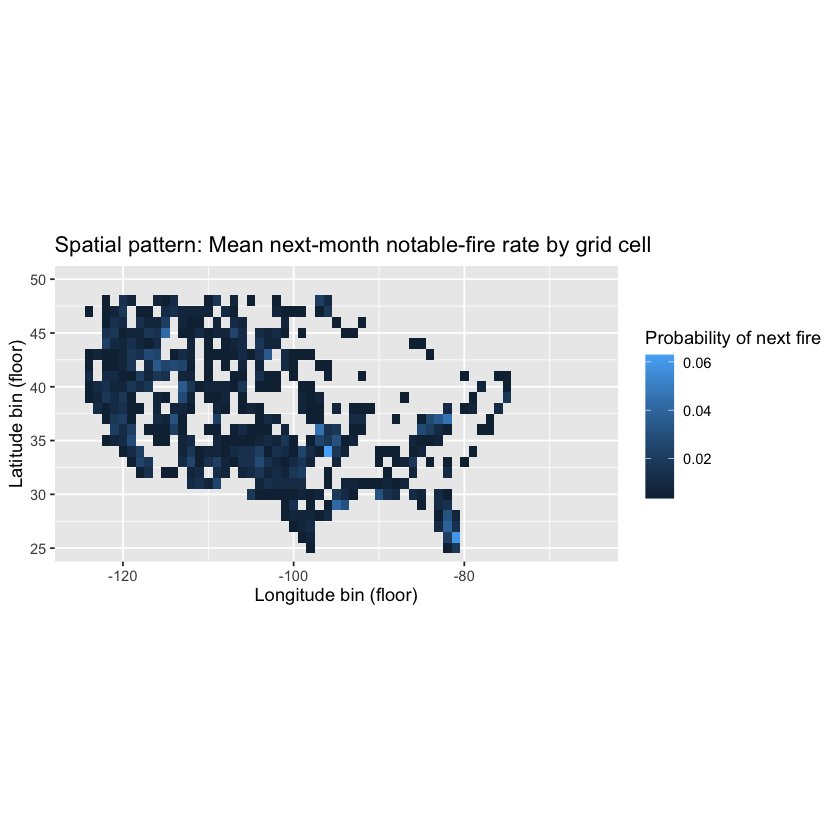

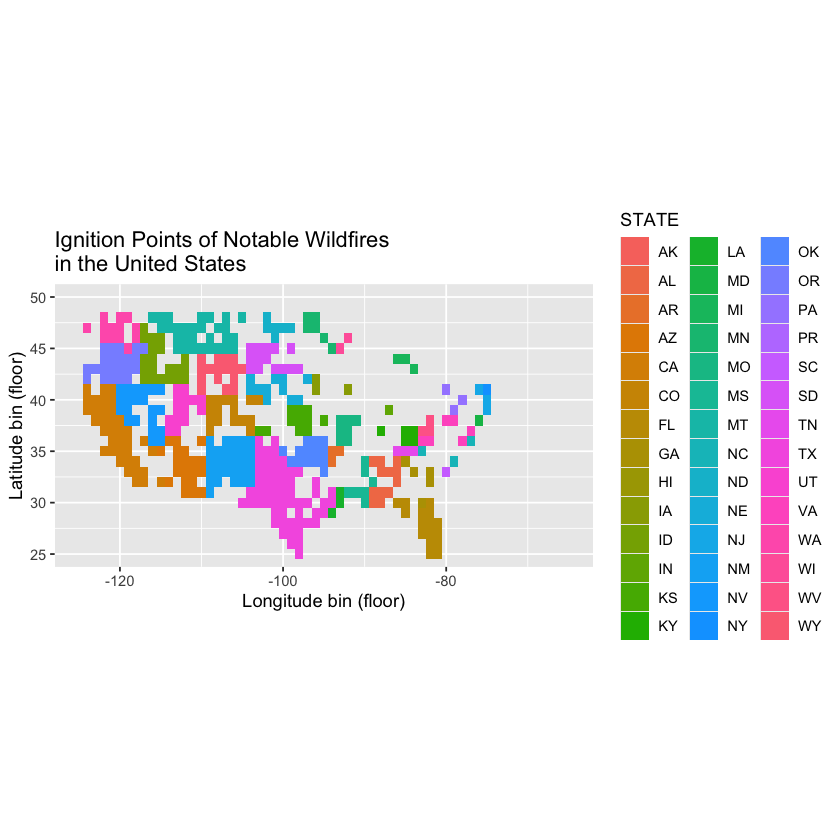

In [390]:
ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = prob_next_fire)) +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  geom_tile() +
  labs(
    title = "Spatial pattern: Mean next-month notable-fire rate by grid cell",
    x = "Longitude bin (floor)",
    y = "Latitude bin (floor)",
    fill = "Probability of next fire"
  )

ggplot(wildfires_300, aes(x = lon_bin, y = lat_bin, fill = STATE)) +
    coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
    geom_tile() +
    labs(title = "Ignition Points of Notable Wildfires\nin the United States",
         x = "Longitude bin (floor)",
         y = "Latitude bin (floor)")



Probability of notable wildfires occuring next month seems to be higher in the West Coast and South West regions of the United States, particularly in states such as California, Oregon, Idaho, Oklahoma, Arizona, and Texas, in which Oklahoma might have the highest probability of notable fire occurence. In the South, West Virginia and Florida shows higher probability than the rest of the region. 

The Midwest has notably sparse ignition points, and therefore has lowest rate of notable fire ignition of the country. 

Overall, probability of notable wildfire occuring next month seems higher in regions that usually have lower humidity, higher temperature, and locate at the border of the country. The analysis shows that the spatial factor of the training data reflects the realitiy of how these locations are more proned to wildfires due to their geography and climates. 

#### Temporal EDA

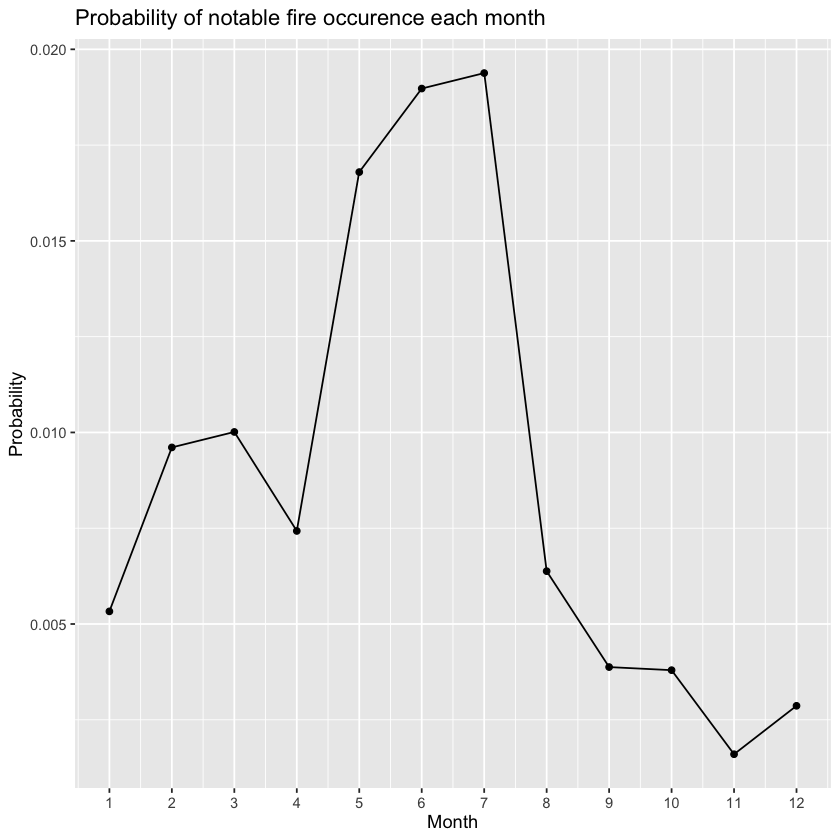

In [386]:
eda_temporal <- panel_new |>
    group_by(month) |>
    summarise(
         prob_next_fire = mean(y_next),
        .groups = "drop")

ggplot(eda_temporal, aes(x = month, y = prob_next_fire)) +
    geom_line() + 
    geom_point() + 
    scale_x_continuous(breaks = 1:12) +
    labs(title = "Probability of notable fire occurence each month",
         x = "Month",
         y = "Probability")


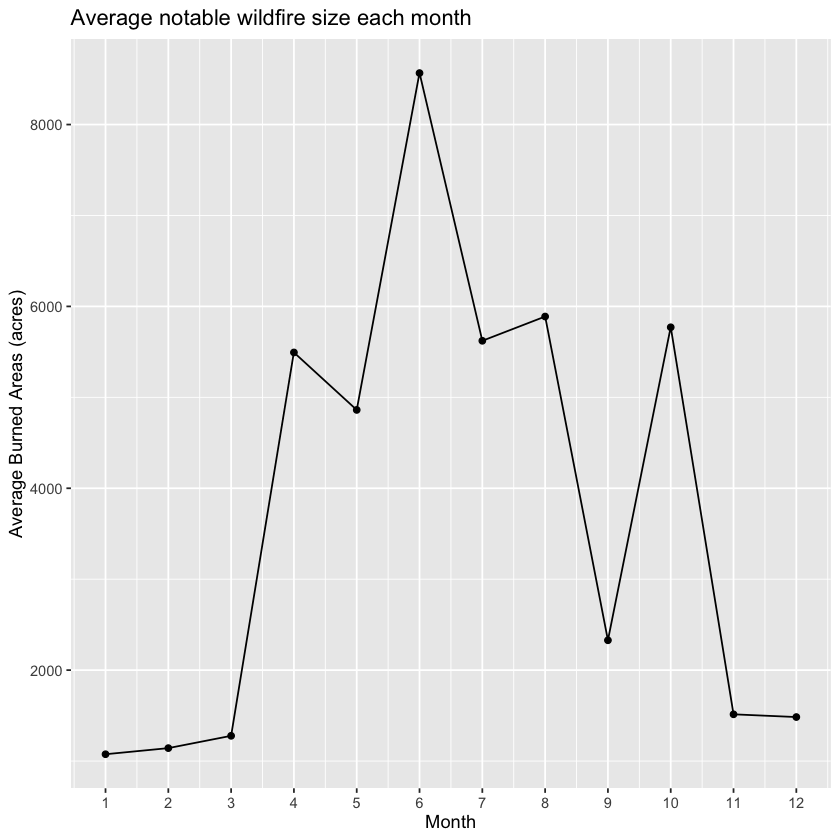

In [387]:
temporal_2 <- wildfires_300 |>
    select(MONTH, FIRE_SIZE)
temporal_2 <- temporal_2 |>
    group_by(MONTH) |>
    summarise(
        mean_fire_size = mean(FIRE_SIZE),
        .groups = "drop")

ggplot(temporal_2, aes(x = MONTH, y = mean_fire_size)) +
    geom_line() + 
    geom_point() + 
    scale_x_continuous(breaks = 1:12) +
    labs(title = "Average notable wildfire size each month",
         x = "Month",
         y = "Average Burned Areas (acres)")


As expected, the probability of notable fire occurence is the highest during the summer, between May and July, and lowest towards the end of the year, from September to December. The intensity of fire, measured by acres burned, for each month from the reported years was also plotted to see if burned acres is an effective predictor. Highest average intensity was captured during the month of June. Other months in summer shows relatively similar intensity, but still notably higher than those in the winter. October also shows a higher average intensity compared to other months in fall and winter. 

Overall, the intensity of notable fires in each month, though shows some discrepancy with the probability of notable fire occurence, still captures that summer time is when notable fires with high intensity can occur, which overlapping the time window of highest probability of notable fire. The observation shows that, even though `FIRE_SIZE` is highly skewed, the predictor can still be informative for the training of the prediction model. 

### Modeling

We fit 3 models:

(1) **Logisitic Regression**

(2) **Classification Tree**

(3) **Naive Bayes**

In [274]:
#Setting up data frame for modeling
model_df <- panel_new |>
  mutate(y_next = factor(y_next, levels = c(0, 1))) |>
  select(y_next, lat_bin, lon_bin, state, 
         month_cos, month_sin, year, 
         n_fires, fire_size)

model_df <- as_tibble(model_df)
head(model_df)

y_next,lat_bin,lon_bin,state,month_cos,month_sin,year,n_fires,fire_size
<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,17,-67,PR,8.660254e-01,5.000000e-01,1992,0,0
0,17,-67,PR,5.000000e-01,8.660254e-01,1992,0,0
0,17,-67,PR,6.123234e-17,1.000000e+00,1992,0,0
0,17,-67,PR,-5.000000e-01,8.660254e-01,1992,0,0
0,17,-67,PR,-8.660254e-01,5.000000e-01,1992,0,0
0,17,-67,PR,-1.000000e+00,1.224647e-16,1992,0,0


### Model Fitting and Validation

In [399]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
  n_fires

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
  mutate(
      # Logistic Regression
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- glm(feat_formula, data = train, family = binomial)
              p_hat <- predict(fit, newdata = valid, type = "response")

          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))
      }),
      
      # Classification Tree
      auc_tree = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- rpart(factor(y_next) ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
                            n_fires, data = train, method = "class",
                            control = rpart.control(cp = 0.0001))
              p_hat <- predict(fit, newdata = valid, type = "prob")[, "1"]
          
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))
        }), 
      
      # Naive Bayes    
      auc_NB = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- naiveBayes(feat_formula, data = train)
              p_hat <- predict(fit, newdata = valid)
              p_hat <- as.numeric(as.character(p_hat))
          
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))    
      }))

fold_results

train_end_year,valid_year,auc_glm,auc_tree,auc_NB
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6779766,0.5000000,0.4969121
1995,1996,0.7218072,0.5000000,0.5104847
1996,1997,0.7922604,0.6928989,0.5613666
1997,1998,0.7568157,0.5000000,0.5258916
1998,1999,0.6702197,0.5000000,0.5125467
1999,2000,0.7256549,0.6401827,0.5389019
2000,2001,0.7320698,0.6817910,0.5329640
2001,2002,0.7286275,0.7310028,0.5275065
2002,2003,0.7285496,0.6774965,0.5243110


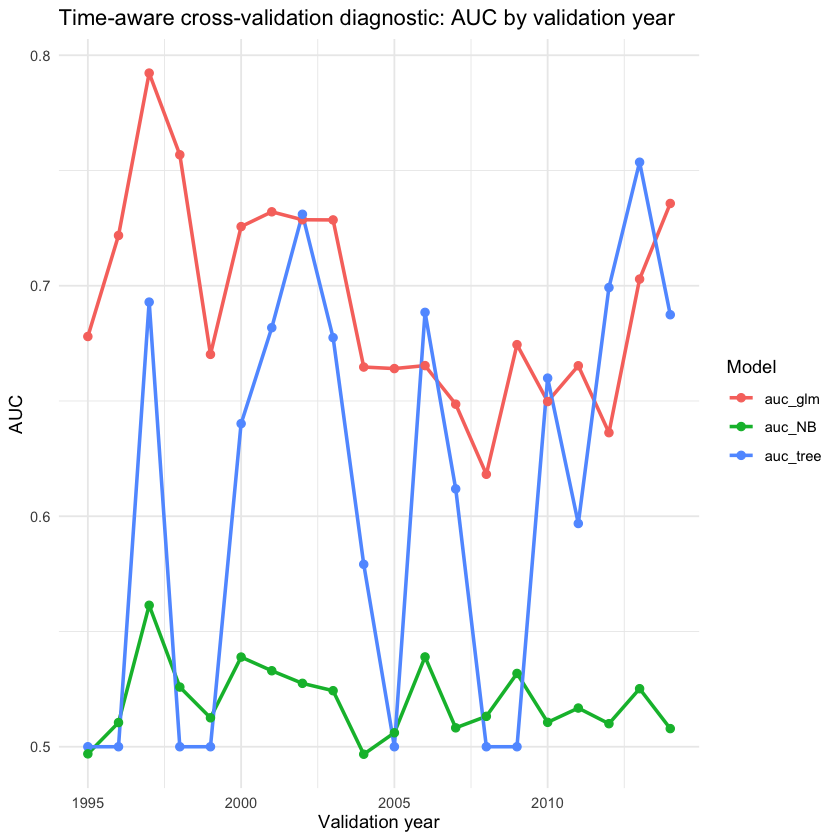

In [165]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_tree, auc_NB),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

#### Tree diagnostics: CV error vs cp


Classification tree:
rpart(formula = factor(y_next) ~ lat_bin + lon_bin + state + 
    month_cos + month_sin + year + n_fires, data = model_df, 
    method = "class", control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
[1] lat_bin   lon_bin   month_cos month_sin n_fires   state     year     

Root node error: 1311/147576 = 0.0088836

n= 147576 

          CP nsplit rel error xerror     xstd
1 0.00010897      0   1.00000 1.0000 0.027495
2 0.00010000     13   0.99847 1.0031 0.027537


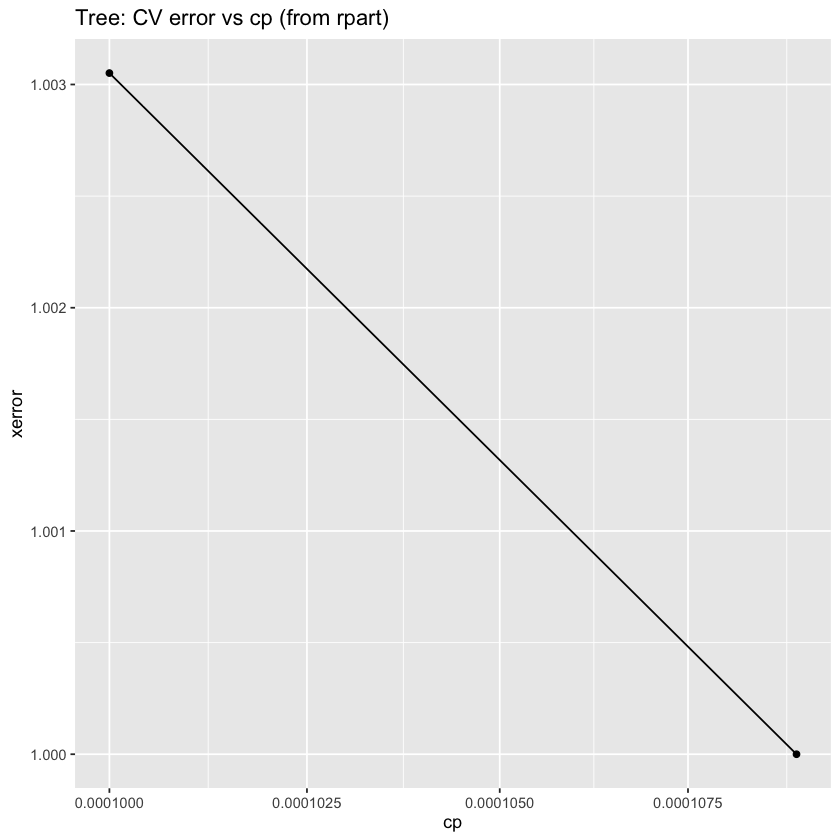

In [401]:
tree_fit <- rpart(factor(y_next) ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
                n_fires, data = model_df, method = "class",
                control = rpart.control(cp = 0.0001))

cp_tbl <- as_tibble(tree_fit$cptable)

ggplot(cp_tbl, aes(CP, xerror)) +
  geom_line() + geom_point() +
  scale_x_log10() +
  labs(title = "Tree: CV error vs cp (from rpart)", x = "cp", y = "xerror")

printcp(tree_fit)


#### Naive Bayes diagnostis: Confusion Matrix

In [336]:
NB_fit <- naiveBayes(y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year + n_fires, data = model_df)
pred <- predict(NB_fit, newdata = model_df)

cm <- table(model_df$y_next, pred)
confusionMatrix(cm)

Confusion Matrix and Statistics

   pred
         0      1
  0 145020   1245
  1   1245     66
                                          
               Accuracy : 0.9831          
                 95% CI : (0.9825, 0.9838)
    No Information Rate : 0.9911          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.0418          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.99149         
            Specificity : 0.05034         
         Pos Pred Value : 0.99149         
         Neg Pred Value : 0.05034         
             Prevalence : 0.99112         
         Detection Rate : 0.98268         
   Detection Prevalence : 0.99112         
      Balanced Accuracy : 0.52092         
                                          
       'Positive' Class : 0               
                                          

#### Discussion 

The AUC was plotted for all prediction models to evaluate their performance for each recorded year from 1992 to 2015. The logistic regression model was able to capture real signals from the predictors consistently, with AUC between 0.6 - 0.75. 

The classification tree model shows more complexity in perfoming prediction, which resulted in boderline random prediction of the binary outcome in several years (AUC close to 0.5 in some cases). The performance of the decision tree was evaluated by manipulating `cp` value, or complexity parameter: at `cp` = 0.001, the tree shows no splits (data not shown), while at `cp` = 0.0001, there are 13 splits and model shows some signals other than random predictions. However, the trade-off is the increase in `xerror`, which signifies a sign of overfitting. The complications in using decision tree might be due to highly imbalanced training data, which is the "root" of the decision tree. Skewness in input data is an inherent characteristic for predicting rare events such as notable fire, where number of no fire is much higher than positive fire incidents. 

The Naive Bayes model performs most poorly among the three models. Since the model operates under the assumptions that the input variables are all independent of one another, it could not capture the interaction between the predictors, such as coordination and state, or acres burned and seasons of the year denoted by months, resulting in random guessing with AUC consistently around 0.5. Interstingly, the Confusion Matrix shows 0.98 accuracy rate. Since most of the training data contains negative fires, the model almost always predicts `0` fires accurately, which makes accuracy rate very misleading. With a small fraction of positive fire training input, Naive Bayes model suffers the same fate as the decision tree with regards to performing prediction for rare-event incidents. 

### 5. Summary

#### EDA

To predict notable fire occurrence, both spatical and seasonality factors were taken into account when designing the training model. Given the uneven distribution of notable fires across the US as well as high probability of fire incidents during the summer, the predictors, such as the coordinates and months, were included and well-transformed to capture these characteristics, supporting the performance of the predictive models. 

#### Modeling
The three models show different levels of predictive performance, due to different assumptions and mathematical principles: Logistic regression model shows relatively stable performance at moderate strength of prediction, but due to the assumptions of linearity among predictors, the model is unable to capture non-linear relationships; Classification tree is able to capture some signals from the predictors, but shows high instability in performance and requires further polishing and parameters evaluation; Naive Bayes model is unfit to perform prediction on a data set with highly interactive variables. Overall, rare-event prediction task with high-order interactive variables requires more powerful and effective pre

#### 